# `rho_gedf` scan against ACT DR6 residuals

This notebook scans
`rho_gedf = [20., 40., 60., 80., 100., 120.]`
with the repository's GEDF-enabled `classy` build and compares the resulting CMB bandpower shifts against the official ACT DR6.02 `cmb-only` bandpowers.

The residual zero-line is the published ACT DR6.02 best-fit LCDM spectrum from LAMBDA, and the error bars come from the diagonal of the ACT DR6 covariance matrix.

Note: `pyactlike` targets ACTPol DR4, while ACT DR6 uses the newer DR6.02 SACC products. For that reason this notebook reads the official DR6 files directly instead of relying on `pyactlike`.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import shutil
import sys
import tarfile
import urllib.request

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 130


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'python' / 'classy.pyx').exists() and (candidate / 'include' / 'background.h').exists():
            return candidate
    raise FileNotFoundError('Could not find the CLASS repository root from the current notebook location.')


REPO_ROOT = find_repo_root()
build_root = REPO_ROOT / 'build'
tag = f'cpython-{sys.version_info.major}{sys.version_info.minor}'

for build_lib in sorted(build_root.glob(f'lib.*{tag}')):
    sys.path.insert(0, str(build_lib))

classy = importlib.import_module('classy')
Class = classy.Class
print(f'Using classy from: {classy.__file__}')

GEDF_PARAMS = {
    'ac_gedf': 1.0 / 3400.0,
    's_a_gedf': 100.0,
    'wi_edf': -1.0,
    'wf_edf': 0.5,
}


def smoke_test_gedf_support() -> None:
    probe = Class()
    params = {
        'output': 'tCl,pCl,lCl',
        'lensing': 'yes',
        'l_max_scalars': 32,
        'h': 0.67,
        'omega_b': 0.0224,
        'omega_cdm': 0.12,
        'A_s': 2.1e-9,
        'n_s': 0.965,
        'tau_reio': 0.055,
        'N_ur': 2.0328,
        'N_ncdm': 1,
        'm_ncdm': 0.06,
        'T_ncdm': 0.71611,
        'YHe': 'BBN',
        'recombination': 'HyRec',
        'rho_gedf': 0.0,
        **GEDF_PARAMS,
    }
    try:
        probe.set(params)
        probe.compute()
    except Exception as exc:
        raise RuntimeError(
            'The imported classy module does not appear to support GEDF parameters. '
            'Run the notebook with the repository build of classy.'
        ) from exc
    finally:
        try:
            probe.struct_cleanup()
            probe.empty()
        except Exception:
            pass


smoke_test_gedf_support()


Using classy from: /home/lutein/Projects/class_public-3.3.3-gedf/build/lib.linux-x86_64-cpython-313/classy/__init__.py


In [2]:
CACHE_DIR = REPO_ROOT / 'output' / 'act_dr6_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = 'https://lambda.gsfc.nasa.gov/data/act/pspipe/sacc_files/dr6_data_cmbonly.tar.gz'
BESTFIT_URL = 'https://lambda.gsfc.nasa.gov/data/act/pspipe/best_fits/act_dr6.02_best_fits_dr6_lcdm.tar.gz'

data_tar = CACHE_DIR / 'dr6_data_cmbonly.tar.gz'
bestfit_tar = CACHE_DIR / 'act_dr6.02_best_fits_dr6_lcdm.tar.gz'
data_dir = CACHE_DIR / 'dr6_data_cmbonly'
bestfit_dir = CACHE_DIR / 'act_dr6_bestfits'


def download_if_needed(url: str, target: Path) -> None:
    if target.exists():
        return
    print(f'Downloading {url}')
    with urllib.request.urlopen(url) as response, target.open('wb') as out:
        shutil.copyfileobj(response, out)


def untar_if_needed(archive: Path, destination: Path) -> None:
    if destination.exists():
        return
    destination.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(destination)


download_if_needed(DATA_URL, data_tar)
download_if_needed(BESTFIT_URL, bestfit_tar)
untar_if_needed(data_tar, data_dir)
untar_if_needed(bestfit_tar, bestfit_dir)

data_fits = data_dir / 'v1.0' / 'dr6_data_cmbonly.fits'
bestfit_cmb = bestfit_dir / 'dr6_lcdm_best_fits' / 'cmb.dat'
print(data_fits)
print(bestfit_cmb)


/home/lutein/Projects/class_public-3.3.3-gedf/output/act_dr6_cache/dr6_data_cmbonly/v1.0/dr6_data_cmbonly.fits
/home/lutein/Projects/class_public-3.3.3-gedf/output/act_dr6_cache/act_dr6_bestfits/dr6_lcdm_best_fits/cmb.dat


In [3]:
SPECTRA = {
    'tt': {'data_hdu': 7, 'window_hdu': 3, 'cov_slice': slice(0, 45), 'bestfit_col': 1, 'label': 'TT'},
    'te': {'data_hdu': 8, 'window_hdu': 4, 'cov_slice': slice(45, 90), 'bestfit_col': 2, 'label': 'TE'},
    'ee': {'data_hdu': 9, 'window_hdu': 5, 'cov_slice': slice(90, 135), 'bestfit_col': 6, 'label': 'EE'},
}

act_hdul = fits.open(data_fits)
act_cov = np.asarray(act_hdul[10].data)
cmb_bestfit = np.loadtxt(bestfit_cmb)
bestfit_ell = cmb_bestfit[:, 0].astype(int)
max_bestfit_ell = int(bestfit_ell.max())


def make_full_dl(column: int) -> np.ndarray:
    full = np.zeros(max_bestfit_ell + 1)
    full[bestfit_ell] = cmb_bestfit[:, column]
    return full


def apply_bandpower_window(full_dl: np.ndarray, window_ell: np.ndarray, weights: np.ndarray) -> np.ndarray:
    return weights.T @ full_dl[window_ell]


act = {}
for key, meta in SPECTRA.items():
    data = act_hdul[meta['data_hdu']].data
    win = act_hdul[meta['window_hdu']].data
    window_ell = np.asarray(win['values']).astype(int)
    weights = np.asarray(win['weight'])
    full_baseline = make_full_dl(meta['bestfit_col'])
    baseline_bp = apply_bandpower_window(full_baseline, window_ell, weights)
    cov_block = act_cov[meta['cov_slice'], meta['cov_slice']]

    act[key] = {
        'label': meta['label'],
        'ell_eff': np.asarray(data['ell']),
        'bandpowers': np.asarray(data['value']),
        'baseline_bp': baseline_bp,
        'sigma': np.sqrt(np.diag(cov_block)),
        'window_ell': window_ell,
        'window_weights': weights,
    }

for key in ['tt', 'te', 'ee']:
    item = act[key]
    print(key, item['ell_eff'][:3], item['bandpowers'][:3], item['sigma'][:3])


tt [600.5 650.5 700.5] [2305.01430449 1858.80403605 1903.12868071] [55.26695566 44.66262992 39.89802835]
te [600.5 650.5 700.5] [ 37.22489613 -14.12250465 -87.94801118] [6.14609419 5.15884406 4.33020108]
ee [600.5 650.5 700.5] [20.07460996 32.36415672 36.11281427] [0.44931798 0.60539142 0.67508422]


In [4]:
# ACT DR6.02 LCDM best-fit parameters from the official LAMBDA best-fit table.
ACT_LCDM = {
    'ln10^{10}A_s': 3.06222331,
    'n_s': 0.97117236,
    'omega_b': 0.02246376,
    'omega_cdm': 0.11984573,
    'tau_reio': 0.05536561,
    'theta_s_100_target': 1.04026876,
}

RHO_SCAN = np.array([1e-8, 200., 400., 600., 800., 1000.])
L_MAX = 8501


def theta_s_100_for_h(h: float) -> float:
    cosmo = Class()
    try:
        cosmo.set({
            'h': h,
            'omega_b': ACT_LCDM['omega_b'],
            'omega_cdm': ACT_LCDM['omega_cdm'],
            'ln10^{10}A_s': ACT_LCDM['ln10^{10}A_s'],
            'n_s': ACT_LCDM['n_s'],
            'tau_reio': ACT_LCDM['tau_reio'],
            'N_ur': 2.0328,
            'N_ncdm': 1,
            'm_ncdm': 0.06,
            'T_ncdm': 0.71611,
            'YHe': 'BBN',
            'recombination': 'HyRec',
            'ac_gedf': 1.0 / 3400.0,
            # 's_a_gedf': 10000.0,
            # 'rho_gedf': 0.0,
            's_a_gedf': 3.0,
            'wi_edf': -1.,
            'wf_edf': 1./2.,
        })
        cosmo.compute()
        return cosmo.theta_s_100()
    finally:
        try:
            cosmo.struct_cleanup()
            cosmo.empty()
        except Exception:
            pass


def solve_h_from_theta(theta_target: float, lo: float = 0.55, hi: float = 0.85, steps: int = 24) -> float:
    f_lo = theta_s_100_for_h(lo) - theta_target
    f_hi = theta_s_100_for_h(hi) - theta_target
    if f_lo == 0.0:
        return lo
    if f_hi == 0.0:
        return hi
    if f_lo * f_hi > 0:
        raise RuntimeError('Failed to bracket the ACT theta_s_100 solution in h.')
    for _ in range(steps):
        mid = 0.5 * (lo + hi)
        f_mid = theta_s_100_for_h(mid) - theta_target
        if f_lo * f_mid <= 0:
            hi = mid
            f_hi = f_mid
        else:
            lo = mid
            f_lo = f_mid
    return 0.5 * (lo + hi)


ACT_H = solve_h_from_theta(ACT_LCDM['theta_s_100_target'])
print(f'ACT-matched h = {ACT_H:.8f}')


ACT-matched h = 0.66970335


In [6]:
BASE_PARAMS = {
    'output': 'tCl,pCl,lCl',
    'lensing': 'yes',
    'l_max_scalars': L_MAX,
    'h': ACT_H,
    'omega_b': ACT_LCDM['omega_b'],
    'omega_cdm': ACT_LCDM['omega_cdm'],
    'ln10^{10}A_s': ACT_LCDM['ln10^{10}A_s'],
    'n_s': ACT_LCDM['n_s'],
    'tau_reio': ACT_LCDM['tau_reio'],
    'N_ur': 2.0328,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
    'T_ncdm': 0.71611,
    'YHe': 'BBN',
    'recombination': 'HyRec',
    'ac_gedf': 1.0 / 3400.0,
    's_a_gedf': 3.0,
    'wi_edf': -1.,
    'wf_edf': 1./2.,
}


def classy_dl_spectra(rho_gedf: float) -> dict[str, np.ndarray | float]:
    cosmo = Class()
    try:
        params = dict(BASE_PARAMS)
        params['rho_gedf'] = float(rho_gedf)
        cosmo.set(params)
        cosmo.compute()
        cls = cosmo.lensed_cl(L_MAX)
        bg = cosmo.get_background()
        ell = cls['ell'].astype(int)
        factor = ell * (ell + 1.0) / (2.0 * np.pi)
        return {
            'rho_gedf': float(rho_gedf),
            'f_gedf': cosmo.get_current_derived_parameters(['f_gedf'])['f_gedf'],
            'rho_fraction_max': np.max(bg['(.)rho_gedf'] / bg['(.)rho_tot']),
            'ell': ell,
            'tt': factor * cls['tt'],
            'te': factor * cls['te'],
            'ee': factor * cls['ee'],
            'z': bg['z'],
            'rho_fraction': bg['(.)rho_gedf'] / bg['(.)rho_tot'],
            'Cltt': cls['tt'],
        }
    finally:
        try:
            cosmo.struct_cleanup()
            cosmo.empty()
        except Exception:
            pass


def bandpowerize_from_classy(dl: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    full = {name: np.zeros(L_MAX + 1) for name in ['tt', 'te', 'ee']}
    for name in ['tt', 'te', 'ee']:
        full[name][dl['ell']] = dl[name]
    out = {}
    for name in ['tt', 'te', 'ee']:
        out[name] = apply_bandpower_window(full[name], act[name]['window_ell'], act[name]['window_weights'])
    return out


scan_models = {}
scan_bandpowers = {}
for rho in RHO_SCAN:
    model = classy_dl_spectra(rho)
    scan_models[rho] = model
    scan_bandpowers[rho] = bandpowerize_from_classy(model)

print('Finished', len(scan_bandpowers), 'GEDF models')


Finished 6 GEDF models


[8.59290457e-43 8.62065021e-43 8.64848544e-43 ... 1.03457099e-06
 1.03162267e-06 1.02868145e-06]


/tmp/ipykernel_7685/516632527.py:7: RuntimeWarning: invalid value encountered in divide
  ax.plot(scan_models[200.]['ell'], (scan_models[200.]['tt']- scan_models[400.]['tt'])/scan_models[200.]['tt'])
/tmp/ipykernel_7685/516632527.py:8: RuntimeWarning: invalid value encountered in divide
  ax.plot(scan_models[200.]['ell'], (scan_models[200.]['tt']- scan_models[1000.]['tt'])/scan_models[200.]['tt'])


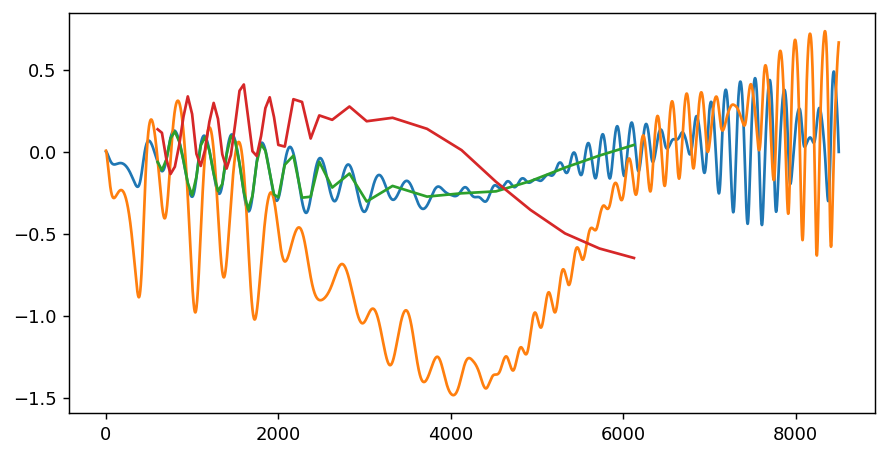

In [35]:
# print(scan_models[200.]['tt'])
# print(scan_bandpowers[200.]['tt'])
print(scan_models[200.]['rho_fraction'])

fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

ax.plot(scan_models[200.]['ell'], (scan_models[200.]['tt']- scan_models[400.]['tt'])/scan_models[200.]['tt'])
ax.plot(scan_models[200.]['ell'], (scan_models[200.]['tt']- scan_models[1000.]['tt'])/scan_models[200.]['tt'])
# ax.plot(scan_models[200.]['ell'], scan_models[200.]['tt']- scan_models[1000.]['tt'])
ax.plot(act['tt']['ell_eff'], (scan_bandpowers[200.]['tt'] - scan_bandpowers[400.]['tt'])/scan_bandpowers[200.]['tt'])
ax.plot(act['tt']['ell_eff'], (scan_bandpowers[200.]['tt']*(2.7255e6 ** 2) - act['tt']['baseline_bp'])/act['tt']['baseline_bp'])
# ax.plot(scan_models[400.]['ell'], scan_models[200.]['tt'])

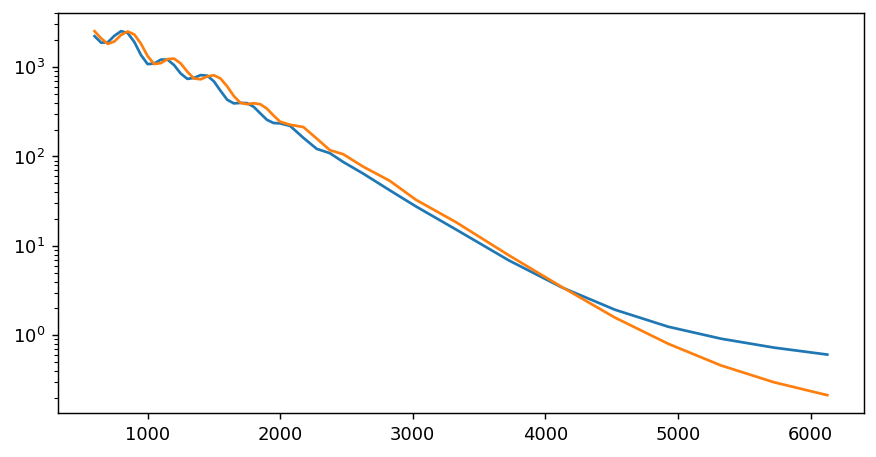

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

# ax.semilogx(scan_models[200.]['z'], scan_models[200.]['rho_fraction'])
# ax.plot(scan_models[200.]['ell'], (scan_models[1e-8]['Cltt']- scan_models[200.]['Cltt'])/scan_models[1e-8]['Cltt'])
ax.semilogy(act['tt']['ell_eff'], act['tt']['baseline_bp'])
ax.semilogy(act['tt']['ell_eff'], scan_bandpowers[200.]['tt']*(2.7255e6 ** 2))
# ax.set_xlim(1e1, 1e5)

In [39]:
print('rho_gedf      f_gedf      max(rho_gedf/rho_tot)   max|TT residual|/sigma  max|TE residual|/sigma  max|EE residual|/sigma')
for rho in RHO_SCAN:
    ratios = []
    for name in ['tt', 'te', 'ee']:
        resid = scan_bandpowers[rho][name] - act[name]['baseline_bp']
        ratios.append(np.max(np.abs(resid) / act[name]['sigma']))
    model = scan_models[rho]
    print(f"{rho:7.1f}  {model['f_gedf']:11.6e}  {model['rho_fraction_max']:20.6e}  {ratios[0]:22.6f}  {ratios[1]:22.6f}  {ratios[2]:22.6f}")

print()
print('Pairwise max residual differences between neighboring rho_gedf scans:')
for name in ['tt', 'te', 'ee']:
    print(f'  {name.upper()}')
    for rho_lo, rho_hi in zip(RHO_SCAN[:-1], RHO_SCAN[1:]):
        delta = np.max(np.abs(scan_bandpowers[rho_hi][name] - scan_bandpowers[rho_lo][name]))
        print(f'    {rho_lo:5.1f} -> {rho_hi:5.1f}: {delta:.6e}')


rho_gedf      f_gedf      max(rho_gedf/rho_tot)   max|TT residual|/sigma  max|TE residual|/sigma  max|EE residual|/sigma
    0.0  8.035523e-12          9.376740e-12              107.527036               52.906094               83.406973
  200.0  1.384587e-01          1.579194e-01              107.527036               52.906094               83.406973
  400.0  2.432389e-01          2.727641e-01              107.527036               52.906094               83.406973
  600.0  3.252960e-01          3.600428e-01              107.527036               52.906094               83.406973
  800.0  3.912987e-01          4.286169e-01              107.527036               52.906094               83.406973
 1000.0  4.455387e-01          4.839173e-01              107.527036               52.906094               83.406973

Pairwise max residual differences between neighboring rho_gedf scans:
  TT
      0.0 -> 200.0: 5.744072e-11
    200.0 -> 400.0: 4.744503e-11
    400.0 -> 600.0: 4.420591e-11
    600.

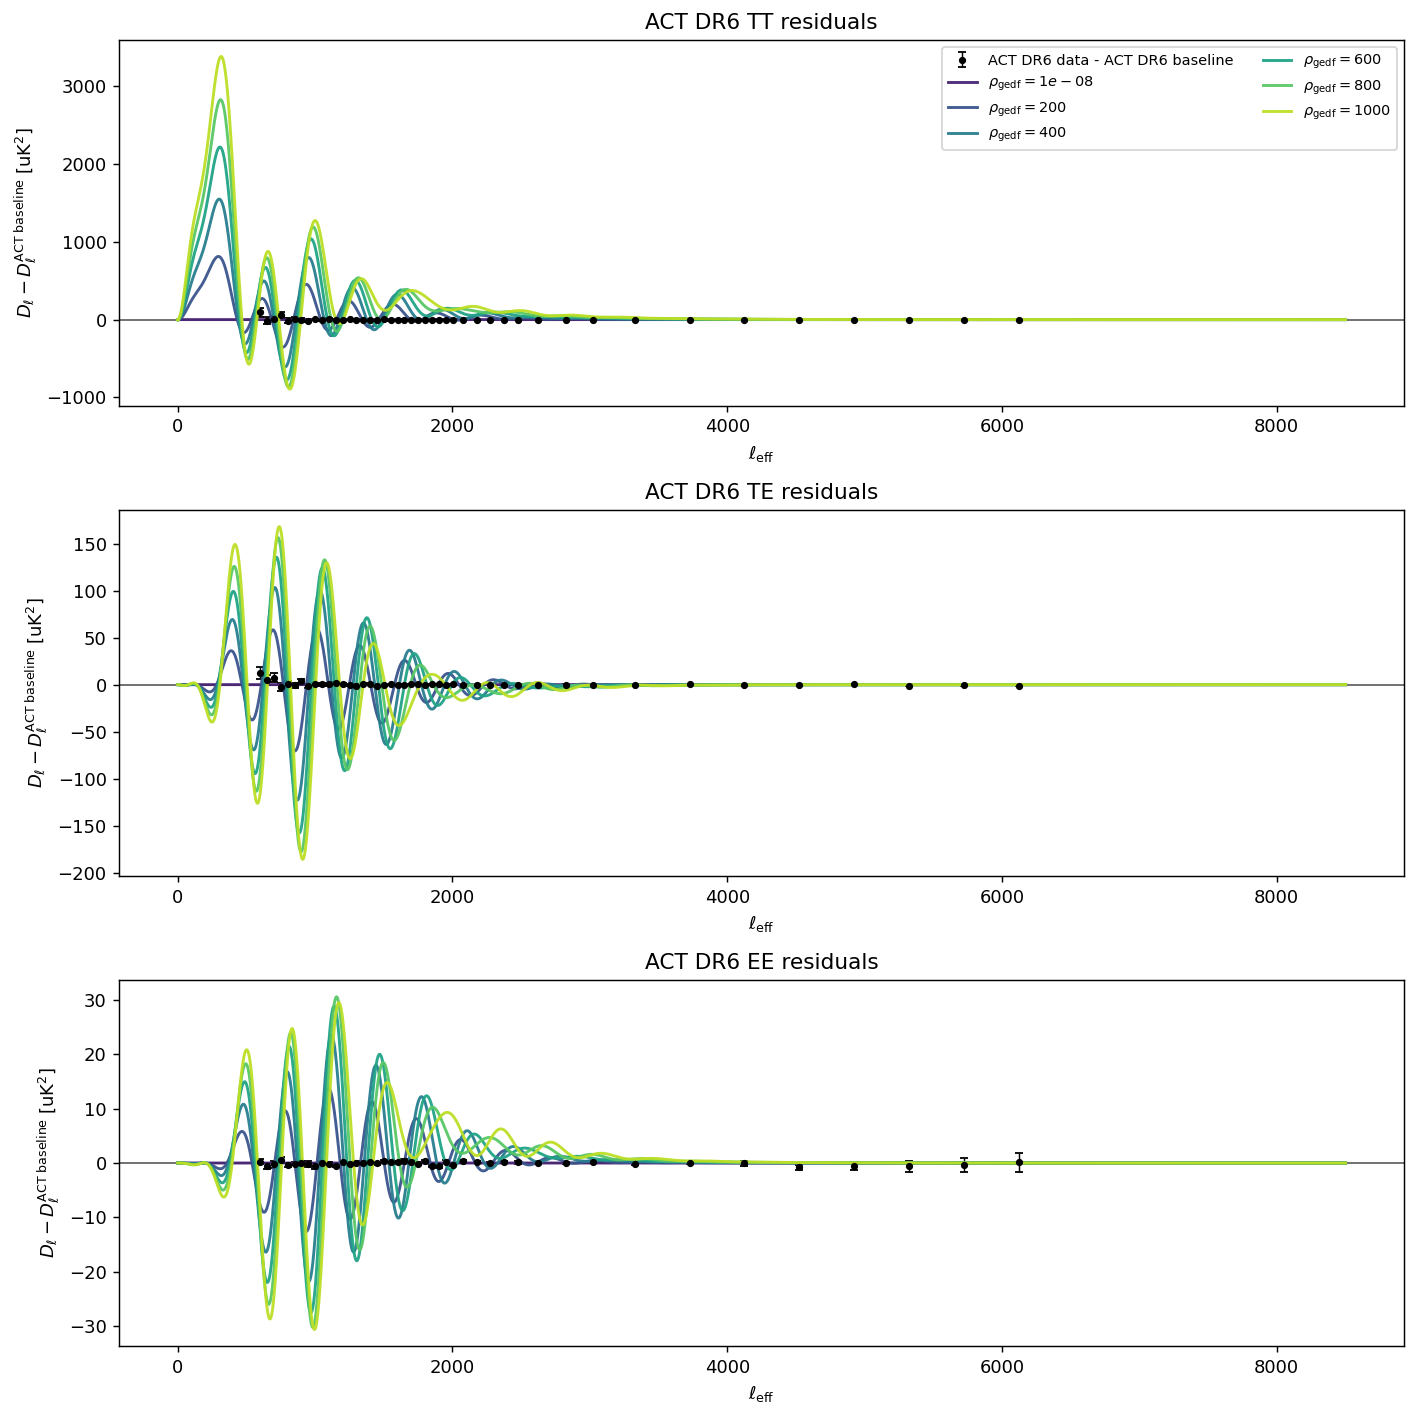

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)
colors = plt.cm.viridis(np.linspace(0.10, 0.90, len(RHO_SCAN)))
line_handles = []

for ax, name in zip(axes, ['tt', 'te', 'ee']):
    item = act[name]
    data_residual = item['bandpowers'] - item['baseline_bp']
    ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
    data_handle = ax.errorbar(
        item['ell_eff'],
        data_residual,
        # item['bandpowers'],
        yerr=item['sigma'],
        fmt='o',
        ms=3,
        lw=0.8,
        capsize=2,
        color='black',
        label='ACT DR6 data - ACT DR6 baseline',
    )
    if not line_handles:
        line_handles.append(data_handle)
    for rho, color in zip(RHO_SCAN, colors):
        model_residual = scan_models[rho][name]*(2.7255e6 ** 2) - scan_models[1e-8][name]*(2.7255e6 ** 2)
        line, = ax.plot(
            # item['ell_eff'],
            scan_models[200.]['ell'],
            model_residual,
            # scan_models[rho][name]*(2.7255e6 ** 2),
            lw=1.6,
            color=color,
            alpha=0.95,
            label=rf'$\rho_{{\rm gedf}}={rho:g}$',
        )
        if len(line_handles) < len(RHO_SCAN) + 1:
            line_handles.append(line)
    ax.set_title(f"ACT DR6 {item['label']} residuals")
    ax.set_xlabel(r'$\ell_\mathrm{eff}$')
    ax.set_ylabel(r'$D_\ell - D_\ell^\mathrm{ACT\ baseline}\;[{\rm uK}^2]$')

legend_labels = ['ACT DR6 data - ACT DR6 baseline'] + [rf'$\rho_{{\rm gedf}}={rho:g}$' for rho in RHO_SCAN]
axes[0].legend(line_handles, legend_labels, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


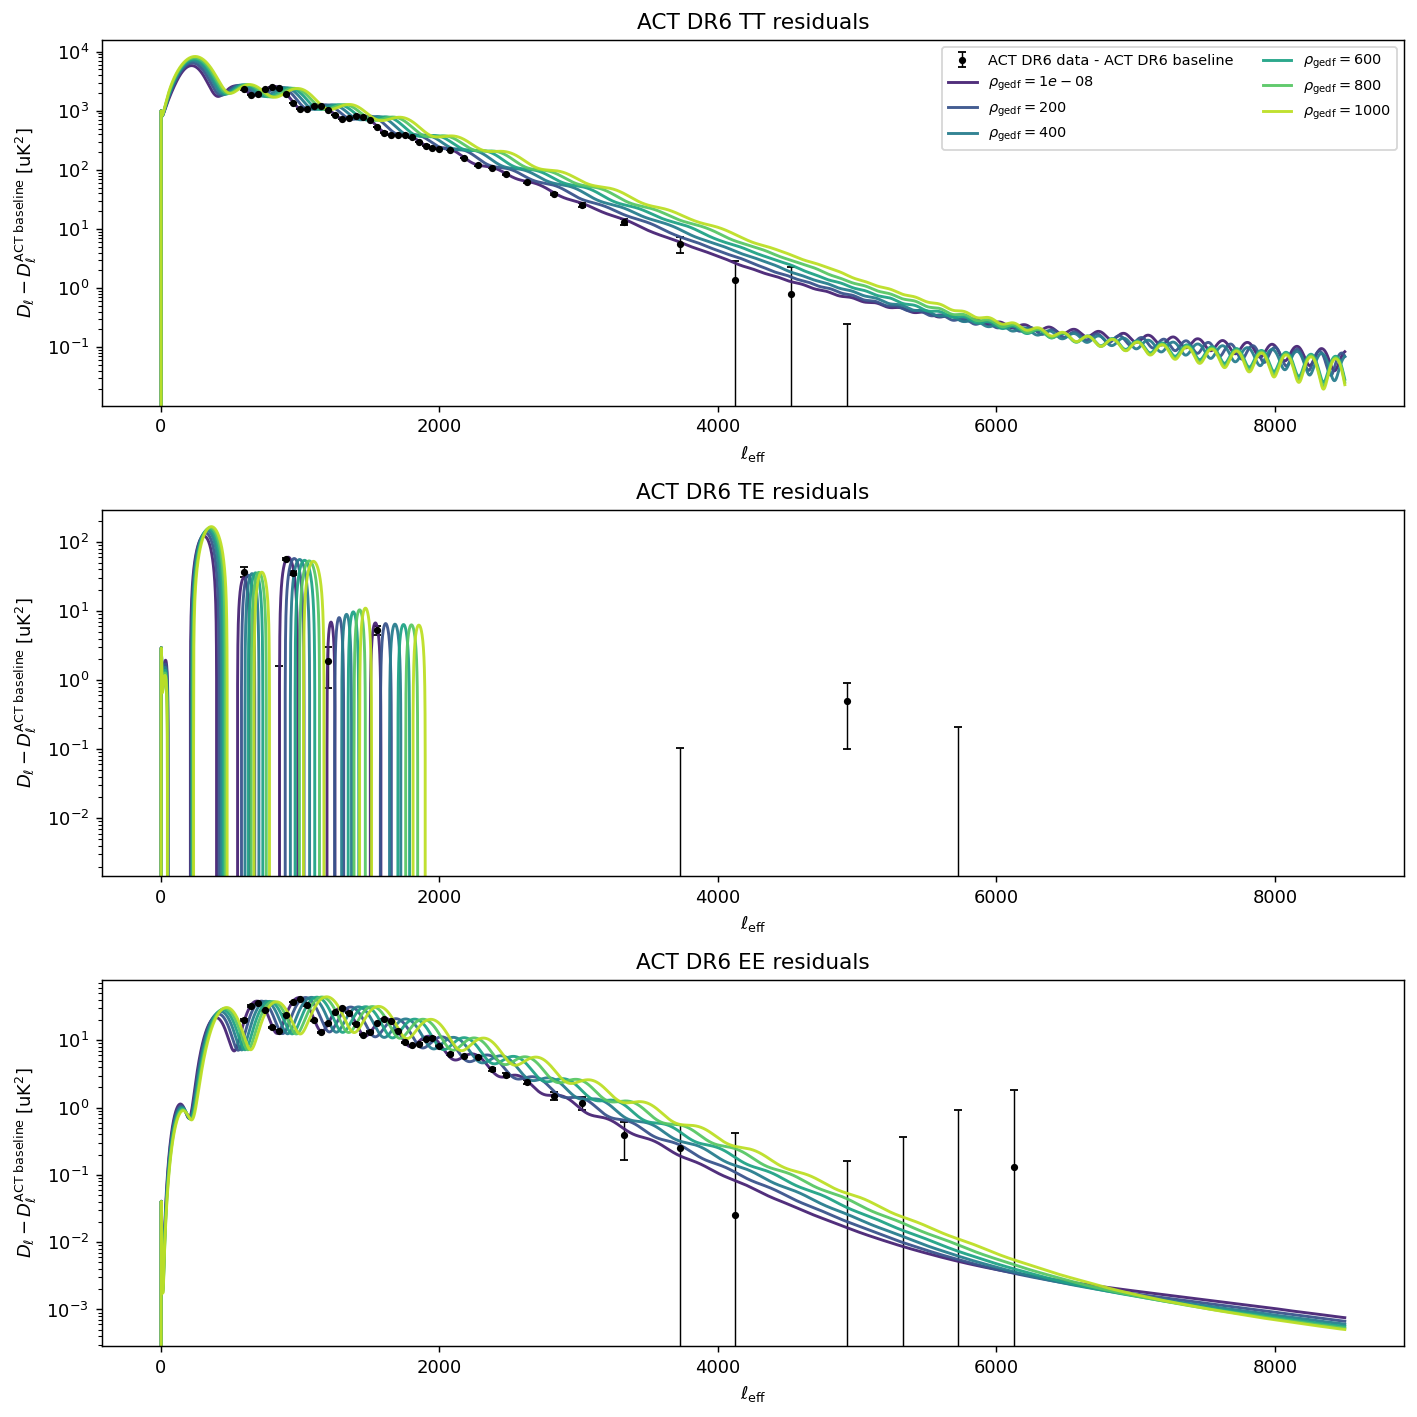

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)
colors = plt.cm.viridis(np.linspace(0.10, 0.90, len(RHO_SCAN)))
line_handles = []

for ax, name in zip(axes, ['tt', 'te', 'ee']):
    item = act[name]
    data_residual = item['bandpowers'] - item['baseline_bp']
    ax.axhline(0.0, color='black', lw=1.0, alpha=0.6)
    data_handle = ax.errorbar(
        item['ell_eff'],
        # data_residual,
        item['bandpowers'],
        yerr=item['sigma'],
        fmt='o',
        ms=3,
        lw=0.8,
        capsize=2,
        color='black',
        label='ACT DR6 data - ACT DR6 baseline',
    )
    if not line_handles:
        line_handles.append(data_handle)
    for rho, color in zip(RHO_SCAN, colors):
        model_residual = scan_models[rho][name]*(2.7255e6 ** 2) - scan_models[1e-8][name]*(2.7255e6 ** 2)
        line, = ax.semilogy(
            # item['ell_eff'],
            scan_models[200.]['ell'],
            # model_residual,
            scan_models[rho][name]*(2.7255e6 ** 2),
            lw=1.6,
            color=color,
            alpha=0.95,
            label=rf'$\rho_{{\rm gedf}}={rho:g}$',
        )
        if len(line_handles) < len(RHO_SCAN) + 1:
            line_handles.append(line)
    ax.set_title(f"ACT DR6 {item['label']} residuals")
    ax.set_xlabel(r'$\ell_\mathrm{eff}$')
    ax.set_ylabel(r'$D_\ell - D_\ell^\mathrm{ACT\ baseline}\;[{\rm uK}^2]$')

legend_labels = ['ACT DR6 data - ACT DR6 baseline'] + [rf'$\rho_{{\rm gedf}}={rho:g}$' for rho in RHO_SCAN]
axes[0].legend(line_handles, legend_labels, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
